In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score

# from lite_org import LITE
from utils import load_data, preprocess_data
import os
from  utils import *

from inception import Classifier_INCEPTION

import warnings
warnings.filterwarnings('ignore')

### Sample codes

In [4]:
model_base.fc1.weight.data[:, all_indices_6]

NameError: name 'all_indices_6' is not defined

In [ ]:
model_pruned.fc1.weight

In [4]:
dataset = 'FordA'
seed = 9409

xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
trainloader = preprocess_data(xtrain, ytrain, shuffle=True)
testloader = preprocess_data(xtest, ytest, shuffle=False)

length_TS = int(xtrain.shape[1])
n_classes=len(np.unique(ytrain))
models_base, models_sparse, models_pruned = [], [], []
num_params_pruned, num_params_base = 0, 0

input_shape = xtrain.shape[1:]
nb_classes = len(np.unique(ytrain))

model_base = Classifier_INCEPTION(input_shape, nb_classes)
model_base.load_state_dict(torch.load(os.getcwd() + f'/results_inception/base_models/base_seed_{seed}/{dataset}/best_model.pt'))
model_base.cuda()
model_base.train()

model_pruned = torch.load(os.getcwd() + f'/results_inception/base_models_1e-5_weights_4_2_1/ins_sparse_seed_{seed}/{dataset}/pruned_model.pth')

In [ ]:
all_indices_3

In [ ]:
# param_selected = torch.index_select(model_base.inception[3].branch4[1].weight.data, 0, conv_groups_layer_4[3])
# param_selected = torch.index_select(param_selected, 1, all_indices_3)
# param_selected[0]    
model_base.inception[5].bn.running_var.data[all_indices_6]

In [ ]:
model_pruned.inception[5].bn.running_var.data

In [7]:
conv_groups_layer_6 =  [torch.tensor([8], device='cuda:0'), 
                        torch.tensor([10], device='cuda:0'), 
                        torch.tensor([], device='cuda:0', dtype=torch.int64), 
                        torch.tensor([], device='cuda:0', dtype=torch.int64)]    

conv_groups_sizes_6 = [1, 1, 0, 0]

all_indices_6 = torch.cat([torch.tensor([8], device='cuda:0'), 
                           torch.tensor([10], device='cuda:0') + 32, 
                           torch.tensor([], device='cuda:0', dtype=torch.int64) + 64, 
                           torch.tensor([], device='cuda:0', dtype=torch.int64) + 96])

In [47]:
conv_groups_layer_5 = [torch.tensor([17, 18], device='cuda:0'), 
                       torch.tensor([], device='cuda:0', dtype=torch.int64), 
                       torch.tensor([], device='cuda:0', dtype=torch.int64), 
                       torch.tensor([], device='cuda:0', dtype=torch.int64)]    

conv_groups_sizes_5 =  [2, 0, 0, 0]

all_indices_5 = torch.cat([torch.tensor([17, 18], device='cuda:0'), 
                       torch.tensor([], device='cuda:0', dtype=torch.int64) + 32, 
                       torch.tensor([], device='cuda:0', dtype=torch.int64) + 64, 
                       torch.tensor([], device='cuda:0', dtype=torch.int64) + 96])

In [3]:
conv_groups_layer_4 =  [torch.tensor([21, 30], device='cuda:0'), 
                        torch.tensor([], device='cuda:0', dtype=torch.int64), 
                        torch.tensor([], device='cuda:0', dtype=torch.int64), 
                        torch.tensor([ 0,  4, 10, 12, 21], device='cuda:0')]    

conv_groups_sizes_4 = [2, 0, 0, 5]

all_indices_4 = torch.cat([torch.tensor([21, 30], device='cuda:0'), 
                           torch.tensor([], device='cuda:0', dtype=torch.int64) + 32, 
                           torch.tensor([], device='cuda:0', dtype=torch.int64) + 64, 
                           torch.tensor([ 0,  4, 10, 12, 21], device='cuda:0' ) + 96]    )

In [4]:
conv_groups_layer_3 = [torch.tensor([ 0,  1,  8,  9, 10, 18, 22, 27, 28, 31], device='cuda:0'), 
                       torch.tensor([11, 12, 19, 22, 23], device='cuda:0'), 
                       torch.tensor([], device='cuda:0', dtype=torch.int64), 
                       torch.tensor([ 0,  1,  9, 14, 16, 26, 30], device='cuda:0')]    
conv_groups_sizes_3 =  [10, 5, 0, 7]

all_indices_3 = torch.cat([torch.tensor([ 0,  1,  8,  9, 10, 18, 22, 27, 28, 31], device='cuda:0'), 
                           torch.tensor([11, 12, 19, 22, 23], device='cuda:0') + 32, 
                           torch.tensor([], device='cuda:0', dtype=torch.int64) + 64, 
                           torch.tensor([ 0,  1,  9, 14, 16, 26, 30], device='cuda:0') + 96]   )

In [5]:
conv_groups_layer_2 =   [torch.tensor([ 0,  3,  4,  6,  9, 10, 12, 16, 17, 21, 23, 24, 27, 28, 29, 30, 31], device='cuda:0'), 
                         torch.tensor([ 0,  4, 20, 30], device='cuda:0'), 
                         torch.tensor([ 3,  9, 11, 15, 17, 19, 22, 25, 28, 29], device='cuda:0'), 
                         torch.tensor([ 0,  5,  6, 10, 16, 23, 29, 31], device='cuda:0')]    

conv_groups_sizes_2 = [17, 4, 10, 8]

all_indices_2 =  torch.cat([torch.tensor([ 0,  3,  4,  6,  9, 10, 12, 16, 17, 21, 23, 24, 27, 28, 29, 30, 31], device='cuda:0'), 
                            torch.tensor([ 0,  4, 20, 30], device='cuda:0') + 32, 
                            torch.tensor([ 3,  9, 11, 15, 17, 19, 22, 25, 28, 29], device='cuda:0') + 64, 
                            torch.tensor([ 0,  5,  6, 10, 16, 23, 29, 31], device='cuda:0') + 96]    )

In [2]:
from inception import Classifier_INCEPTION
dataset_names = [ 
                    'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
                    'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  'BME', 'Car', 'CBF', 'Chinatown',
                    'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
                    'CricketY', 'CricketZ', 
                    'DiatomSizeReduction',
                    'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
                    'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
                    'ECG5000', 'ECGFiveDays',  'EOGHorizontalSignal', 'EthanolLevel', 
                    'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
                    'FiftyWords', 'Fish', 'FreezerRegularTrain',
                    'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
                    'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
                    'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
                    'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
                    'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
                    'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
                    'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
                    'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
                    'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
                    'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
                    'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
                    'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
                    'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
                    'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
                    'Rock', 'ScreenType', 'SemgHandGenderCh2', 'SemgHandMovementCh2',
                    'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
                    'SmallKitchenAppliances', 'SmoothSubspace', 'SonyAIBORobotSurface1',
                    'SonyAIBORobotSurface2', 'StarLightCurves', 'Strawberry', 'SwedishLeaf',
                    'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 'Trace',
                    'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
                    'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
                    'UWaveGestureLibraryZ', 'Wafer',  'Worms', 'WormsTwoClass',     
                                    
                    'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
                    
                    ]

dataset_names = ['FordA']
columns=['Dataset', 'base_red_1', 'base_red_2', 'base_red_3',  'sparse_red_1', 'sparse_red_2', 'sparse_red_3',]
# columns=['Dataset', 'base_red_3',  'sparse_red_3',]

redundancy_df = pd.DataFrame(columns=columns)
seed = 9409

for dataset in dataset_names:
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, mini_batch_size=64)
    testloader = preprocess_data(xtest, ytest, mini_batch_size=64)
    
    input_shape = xtrain.shape[1:]
    nb_classes = len(np.unique(ytrain))
    
    model_base = Classifier_INCEPTION(input_shape, nb_classes, nb_filters=np.array([[32, 32, 32, 32],
                                                                                    [32, 32, 32, 32],
                                                                                    [32, 32, 32, 32],
                                                                                    [32, 32, 32, 32],
                                                                                    [32, 32, 32, 32],
                                                                                    [32, 32, 32, 32]]),)
                                      
                                      
    # model_base.load_state_dict(torch.load(os.getcwd() + f'/results_inception/base_models/base_seed_{seed}/{dataset}/best_model.pt'))
    
    # model_base.cuda()
    # model_base.eval()
     
    
    # features_dict = {1: [], 2: [], 3: [], 4: [], 5: [], 6: []}

    # with torch.no_grad():
    #     for b_idx, (input, target) in enumerate(trainloader):
    #         input, target = input.cuda(), target.cuda()
    #         output, features = model_base.extract_features(input.float())
    #         features_dict[1].append(features[0])
    #         features_dict[2].append(features[1])
    #         features_dict[3].append(features[2])
    #         features_dict[4].append(features[3])
    #         features_dict[5].append(features[4])
    #         features_dict[6].append(features[5])


    # features_dict[1] = torch.cat(features_dict[1], dim=0)
    # features_dict[2] = torch.cat(features_dict[2], dim=0)
    # features_dict[3] = torch.cat(features_dict[3], dim=0)
    # features_dict[4] = torch.cat(features_dict[4], dim=0)
    # features_dict[5] = torch.cat(features_dict[5], dim=0)
    # features_dict[6] = torch.cat(features_dict[6], dim=0)

    
    # print('\n-----------------------------------------------------------------------------------------------------------\n')
    
 

In [ ]:
feat_map = features_dict[5][0].detach().cpu()
# feat_map = tmp.detach().cpu()

print('feat map shape: ', feat_map.shape)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(45, 15))
sns.heatmap(feat_map, annot=False, cbar=True )
plt.xticks([])  
plt.yticks([])  
plt.savefig('tmp.pdf')
plt.show()
plt.close()

In [ ]:
columns=['Dataset', 'base_red_1', 'base_red_2', 'base_red_3',  'sparse_red_1', 'sparse_red_2', 'sparse_red_3',]

redundancy_df = pd.DataFrame(columns=columns)
seeds = [9409]
models_base = []
for dataset in dataset_names:
    for seed in seeds:
        rows = [dataset]
        xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
        trainloader = preprocess_data(xtrain, ytrain, mini_batch_size=64)
        testloader = preprocess_data(xtest, ytest, mini_batch_size=64)
        
        input_shape = xtrain.shape[1:]
        nb_classes = len(np.unique(ytrain))

        model_base = Classifier_INCEPTION(input_shape, nb_classes)
        model_base.load_state_dict(torch.load(os.getcwd() + f'/results_inception/base_models_1e-5_weights_4_2_1/ins_sparse_seed_{seed}/{dataset}/best_model.pt'))
        model_base.cuda()
        model_base.eval()
        models_base.append(model_base)
        
        features_dict = {1: [], 2: [], 3: [], 4: [], 5: [], 6: []}

        with torch.no_grad():
            for b_idx, (input, target) in enumerate(trainloader):
                input, target = input.cuda(), target.cuda()
                output, features = model_base.extract_features(input.float())
                features_dict[1].append(features[0])
                features_dict[2].append(features[1])
                features_dict[3].append(features[2])
                features_dict[4].append(features[3])
                features_dict[5].append(features[4])
                features_dict[6].append(features[5])

        features_dict[1] = torch.cat(features_dict[1], dim=0)
        features_dict[2] = torch.cat(features_dict[2], dim=0)
        features_dict[3] = torch.cat(features_dict[3], dim=0)
        features_dict[4] = torch.cat(features_dict[4], dim=0)
        features_dict[5] = torch.cat(features_dict[5], dim=0)
        features_dict[6] = torch.cat(features_dict[6], dim=0)

        print('\n-----------------------------------------------------------------------------------------------------------\n')

In [ ]:
feat_map = features_dict[5][0].detach().cpu()
# feat_map = tmp.detach().cpu()

print('feat map shape: ', feat_map.shape)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(45, 15))
sns.heatmap(feat_map, annot=False, cbar=True )
plt.xticks([])  
plt.yticks([])  
plt.savefig('tmp.pdf')
plt.show()
plt.close()

## Identfying redundant part of the Inception model

In [4]:
def conv_groups_per_layer(mask):
    # Sixth layer
    tmp = mask.sum(dim=0) # (num of filters)
    indicies, conv_size  = torch.where(tmp > 0)[0], torch.where(tmp > 0)[0].shape[0]        
        
    conv_group_1 = indicies[indicies < 32]
    conv_group_2 = indicies[(indicies >= 32) & (indicies < 64)]
    conv_group_3 = indicies[(indicies >= 64) & (indicies < 96)]
    conv_group_4 = indicies[indicies >= 96]


    conv_group_2 = conv_group_2 - 32
    conv_group_3 = conv_group_3 - 64
    conv_group_4 = conv_group_4 - 96
    
    print('hmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmm: ', conv_group_1.shape[0] + conv_group_2.shape[0] + conv_group_3.shape[0] + conv_group_4.shape[0])
    if conv_group_1.shape[0] + conv_group_2.shape[0] + conv_group_3.shape[0] + conv_group_4.shape[0] == 0:
        print('summmmmmmmmmmmmmmmmmmmmmmm')
        conv_group_1 = torch.tensor([0], device=indicies.device)
        conv_group_2 = torch.tensor([0], device=indicies.device)
    
    elif conv_group_1.shape[0] + conv_group_2.shape[0] + conv_group_3.shape[0] + conv_group_4.shape[0] == 1:
        if conv_group_1.shape[0] == 0:
            conv_group_1 = torch.tensor([0], device=indicies.device)
        elif conv_group_2.shape[0] == 0:
            conv_group_2 = torch.tensor([0], device=indicies.device)
        elif conv_group_3.shape[0] == 0:
            conv_group_3 = torch.tensor([0], device=indicies.device)
        elif conv_group_4.shape[0] == 0:
            conv_group_4 = torch.tensor([0], device=indicies.device)

            

    conv_groups_layer = [conv_group_1, conv_group_2, conv_group_3, conv_group_4]
    
    return conv_groups_layer, [conv_group_1.shape[0], conv_group_2.shape[0], conv_group_3.shape[0], conv_group_4.shape[0]]


def copy_params(base_model, pruned_model, conv_groups_layer_1, conv_groups_layer_2, conv_groups_layer_3, conv_groups_layer_4,
                                   conv_groups_layer_5, conv_groups_layer_6, out_dir):
    # print(f'conv_groups_layer_1: {conv_groups_layer_1}')
    # print(f'conv_groups_layer_2: {conv_groups_layer_2}')
    # print(f'conv_groups_layer_3: {conv_groups_layer_3}')
    # print(f'conv_groups_layer_4: {conv_groups_layer_4}')
    # print(f'conv_groups_layer_5: {conv_groups_layer_5}')
    # print(f'conv_groups_layer_6: {conv_groups_layer_6}')
    
    model_base_state_dict = base_model.state_dict()
    model_pruned_state_dict = pruned_model.state_dict()

    for name, param in model_base_state_dict.items():
        print(f'Name: {name}')
        print()
        if 'num_batches_tracked' in name:
            continue
        
        # Only proceed if the layer exists in the pruned model
        if name not in model_pruned_state_dict:
            print(f"[Skip] {name} not in pruned model")
            continue
        
        ###################################################   LAYER 1   ###################################################
        elif 'inception.0.branch1.weight' in name: 
            model_pruned_state_dict[name] = param[conv_groups_layer_1[0]].clone()
            print(f'conv_groups_layer_1[0]: {conv_groups_layer_1[0]}')
            # print(' 111 **************************************\n\n')
            
        elif 'inception.0.branch2.weight' in name:            
            model_pruned_state_dict[name] = param[conv_groups_layer_1[1]].clone()
            print(f'conv_groups_layer_1[1]: {conv_groups_layer_1[1]}')
            
            # print(' 222 **************************************\n\n')
            
        elif 'inception.0.branch3.weight' in name:
            model_pruned_state_dict[name] = param[conv_groups_layer_1[2]].clone()
            print(f'conv_groups_layer_1[2]: {conv_groups_layer_1[2]}')
            
            # print(' 333 **************************************\n\n')
        
        elif 'inception.0.branch4.1.weight' in name:
            model_pruned_state_dict[name] = param[conv_groups_layer_1[3]].clone()
            # print(' 333 **************************************\n\n')
            print(f'conv_groups_layer_1[3]: {conv_groups_layer_1[3]}')


        elif 'inception.0.bn' in name:
            all_indices = torch.cat((conv_groups_layer_1[0], conv_groups_layer_1[1]+32, conv_groups_layer_1[2]+64 , conv_groups_layer_1[3] + 96))
            all_indices_1 = all_indices
            print('all_indices: ', all_indices)
            model_pruned_state_dict[name] = param[all_indices].clone()            
            print(' 555 **************************************')
            



        ###################################################   LAYER 2   ###################################################
        elif 'inception.1.bottleneck.weight' in name:
            # model_pruned_state_dict[name] = param[:, all_indices, :].clone()         
            model_pruned_state_dict[name] = param[:, all_indices, :].clone()                           
            print(f'Name: {name}   and   param.shape: {param.shape}')
            print('The bottleneck works well')
            
        
        elif 'inception.1.branch1.weight' in name: 
            model_pruned_state_dict[name] = param[conv_groups_layer_2[0]].clone()
            print(f'conv_groups_layer_2[0]: {conv_groups_layer_2[0]}')
            # print(' 111 **************************************\n\n')
            
        elif 'inception.1.branch2.weight' in name:            
            model_pruned_state_dict[name] = param[conv_groups_layer_2[1]].clone()
            print(f'conv_groups_layer_2[1]: {conv_groups_layer_2[1]}')
            
            # print(' 222 **************************************\n\n')
            
        elif 'inception.1.branch3.weight' in name:
            model_pruned_state_dict[name] = param[conv_groups_layer_2[2]].clone()
            print(f'conv_groups_layer_2[2]: {conv_groups_layer_2[2]}')
            
            # print(' 333 **************************************\n\n')
        
        elif 'inception.1.branch4.1.weight' in name:
            param_selected = torch.index_select(param, 0, conv_groups_layer_2[3])
            param_selected = torch.index_select(param_selected, 1, all_indices)
            
            model_pruned_state_dict[name] = param_selected.clone()
            # print(' 333 **************************************\n\n')
            print(f'conv_groups_layer_2[3]: {conv_groups_layer_2[3]}')


        elif 'inception.1.bn' in name:
            all_indices = torch.cat((conv_groups_layer_2[0], conv_groups_layer_2[1]+32, conv_groups_layer_2[2]+64 , conv_groups_layer_2[3] + 96))
            all_indices_2 = all_indices
            print('all_indices: ', all_indices)
            model_pruned_state_dict[name] = param[all_indices].clone()
            
            print(' 555 **************************************')
            
            
            
        ###################################################   LAYER 3   ###################################################
        elif 'inception.2.bottleneck.weight' in name:
            model_pruned_state_dict[name] = param[:, all_indices, :].clone()                           
            print(f'Name: {name}   and   param.shape: {param.shape}')
            print('The bottleneck works well')
            
        
        elif 'inception.2.branch1.weight' in name: 
            model_pruned_state_dict[name] = param[conv_groups_layer_3[0]].clone()
            print(f'conv_groups_layer_3[0]: {conv_groups_layer_3[0]}')
            # print(' 111 **************************************\n\n')
            
        elif 'inception.2.branch2.weight' in name:            
            model_pruned_state_dict[name] = param[conv_groups_layer_3[1]].clone()
            print(f'conv_groups_layer_3[1]: {conv_groups_layer_3[1]}')
            
            # print(' 222 **************************************\n\n')
            
        elif 'inception.2.branch3.weight' in name:
            model_pruned_state_dict[name] = param[conv_groups_layer_3[2]].clone()
            print(f'conv_groups_layer_3[2]: {conv_groups_layer_3[2]}')
            
            # print(' 333 **************************************\n\n')
        
        elif 'inception.2.branch4.1.weight' in name:
            param_selected = torch.index_select(param, 0, conv_groups_layer_3[3])
            param_selected = torch.index_select(param_selected, 1, all_indices)
            
            model_pruned_state_dict[name] = param_selected.clone()
            # print(' 333 **************************************\n\n')
            print(f'conv_groups_layer_3[3]: {conv_groups_layer_3[3]}')


        elif 'inception.2.bn' in name:
            all_indices = torch.cat((conv_groups_layer_3[0], conv_groups_layer_3[1]+32, conv_groups_layer_3[2]+64 , conv_groups_layer_3[3] + 96))
            all_indices_3 = all_indices
            print('all_indices: ', all_indices)
            model_pruned_state_dict[name] = param[all_indices].clone()
            
            print(' 555 **************************************')
        
        ###################################################   LAYER 4   ###################################################
        elif 'inception.3.bottleneck.weight' in name:
            model_pruned_state_dict[name] = param[:, all_indices, :].clone()                           
            print(f'Name: {name}   and   param.shape: {param.shape}')
            print('The bottleneck works well')
            
        
        elif 'inception.3.branch1.weight' in name: 
            print('\n *********************************** \n')
            model_pruned_state_dict[name] = param[conv_groups_layer_4[0]].clone()
            print(f'conv_groups_layer_4[0]: {conv_groups_layer_4[0]}')
            # print(' 111 **************************************\n\n')
            
        elif 'inception.3.branch2.weight' in name:            
            model_pruned_state_dict[name] = param[conv_groups_layer_4[1]].clone()
            print(f'conv_groups_layer_4[1]: {conv_groups_layer_4[1]}')
            
            # print(' 222 **************************************\n\n')
            
        elif 'inception.3.branch3.weight' in name:
            model_pruned_state_dict[name] = param[conv_groups_layer_4[2]].clone()
            print(f'conv_groups_layer_4[2]: {conv_groups_layer_4[2]}')            
            # print(' 333 **************************************\n\n')
        
        elif 'inception.3.branch4.1.weight' in name:
            param_selected = torch.index_select(param, 0, conv_groups_layer_4[3])
            param_selected = torch.index_select(param_selected, 1, all_indices)
            
            model_pruned_state_dict[name] = param_selected.clone()
            # print(' 333 **************************************\n\n')
            print(f'conv_groups_layer_4[3]: {conv_groups_layer_4[3]}')


        elif 'inception.3.bn' in name:
            all_indices = torch.cat((conv_groups_layer_4[0], conv_groups_layer_4[1]+32, conv_groups_layer_4[2]+64 , conv_groups_layer_4[3] + 96))
            print('all_indices: ', all_indices)
            model_pruned_state_dict[name] = param[all_indices].clone()
            
            print(' 555 **************************************')


        ###################################################   LAYER 5   ###################################################
        elif 'inception.4.bottleneck.weight' in name:
            model_pruned_state_dict[name] = param[:, all_indices, :].clone()                           
            print(f'Name: {name}   and   param.shape: {param.shape}')
            print('The bottleneck works well')
            
        
        elif 'inception.4.branch1.weight' in name: 
            
            model_pruned_state_dict[name] = param[conv_groups_layer_5[0]].clone()
            print(f'conv_groups_layer_5[0]: {conv_groups_layer_5[0]}')
            # print(' 111 **************************************\n\n')
            
        elif 'inception.4.branch2.weight' in name:            
            model_pruned_state_dict[name] = param[conv_groups_layer_5[1]].clone()
            print(f'conv_groups_layer_5[1]: {conv_groups_layer_5[1]}')
            
            # print(' 222 **************************************\n\n')
            
        elif 'inception.4.branch3.weight' in name:
            model_pruned_state_dict[name] = param[conv_groups_layer_5[2]].clone()
            print(f'conv_groups_layer_5[2]: {conv_groups_layer_5[2]}')
            
            # print(' 333 **************************************\n\n')
        
        elif 'inception.4.branch4.1.weight' in name:
            param_selected = torch.index_select(param, 0, conv_groups_layer_5[3])
            param_selected = torch.index_select(param_selected, 1, all_indices)
            
            model_pruned_state_dict[name] = param_selected.clone()
            # print(' 333 **************************************\n\n')
            print(f'conv_groups_layer_4[3]: {conv_groups_layer_4[3]}')


        elif 'inception.4.bn' in name:
            all_indices = torch.cat((conv_groups_layer_5[0], conv_groups_layer_5[1]+32, conv_groups_layer_5[2]+64 , conv_groups_layer_5[3] + 96))
            print('all_indices: ', all_indices)
            model_pruned_state_dict[name] = param[all_indices].clone()
            
            print(' 555 **************************************')

        ###################################################   LAYER 6   ###################################################
        elif 'inception.5.bottleneck.weight' in name:
            model_pruned_state_dict[name] = param[:, all_indices, :].clone()                           
            print(f'Name: {name}   and   param.shape: {param.shape}')
            print('The bottleneck works well')
            
        
        elif 'inception.5.branch1.weight' in name: 
            model_pruned_state_dict[name] = param[conv_groups_layer_6[0]].clone()
            print(f'conv_groups_layer_6[0]: {conv_groups_layer_6[0]}')
            # print(' 111 **************************************\n\n')
            
        elif 'inception.5.branch2.weight' in name:            
            model_pruned_state_dict[name] = param[conv_groups_layer_6[1]].clone()
            print(f'conv_groups_layer_6[1]: {conv_groups_layer_6[1]}')
            
            # print(' 222 **************************************\n\n')
            
        elif 'inception.5.branch3.weight' in name:
            model_pruned_state_dict[name] = param[conv_groups_layer_6[2]].clone()
            print(f'conv_groups_layer_6[2]: {conv_groups_layer_6[2]}')
            
            # print(' 333 **************************************\n\n')
        
        elif 'inception.5.branch4.1.weight' in name:
            param_selected = torch.index_select(param, 0, conv_groups_layer_6[3])
            param_selected = torch.index_select(param_selected, 1, all_indices)
            
            model_pruned_state_dict[name] = param_selected.clone()
            # print(' 333 **************************************\n\n')
            print(f'conv_groups_layer_4[3]: {conv_groups_layer_4[3]}')


        elif 'inception.5.bn' in name:
            all_indices = torch.cat((conv_groups_layer_6[0], conv_groups_layer_6[1]+32, conv_groups_layer_6[2]+64 , conv_groups_layer_6[3] + 96))
            all_indices_6 = all_indices
            print('all_indices: ', all_indices)
            model_pruned_state_dict[name] = param[all_indices].clone()
            
            print(' 555 **************************************')


            print('Main layers finished')
        ###################################################   SHORTCUT LAYER 1   ###################################################
        elif 'shortcut.0.residual.0.weight' in name: 
            model_pruned_state_dict[name] = param[all_indices_3].clone()
        elif 'shortcut.0.residual.1.weight' in name: 
            model_pruned_state_dict[name] = param[all_indices_3].clone()
        elif 'shortcut.0.residual.1.bias' in name: 
            model_pruned_state_dict[name] = param[all_indices_3].clone()
        elif 'shortcut.0.residual.1.running_mean' in name: 
            model_pruned_state_dict[name] = param[all_indices_3].clone()
        elif 'shortcut.0.residual.1.running_var' in name: 
            model_pruned_state_dict[name] = param[all_indices_3].clone()


        elif 'shortcut.1.residual.0.weight    ' in name: 
            print(f'all_indices_6: {all_indices_3}')
            model_pruned_state_dict[name] = param[all_indices_3].clone()
        elif 'shortcut.1.residual.1.weight' in name: 
            model_pruned_state_dict[name] = param[all_indices_6].clone()
        elif 'shortcut.1.residual.1.bias' in name: 
            model_pruned_state_dict[name] = param[all_indices_6].clone()
        elif 'shortcut.1.residual.1.running_mean' in name: 
            model_pruned_state_dict[name] = param[all_indices_6].clone()
        elif 'shortcut.1.residual.1.running_var' in name: 
            model_pruned_state_dict[name] = param[all_indices_6].clone()


        elif 'fc1.weight' in name: 
            model_pruned_state_dict[name] = param[:, all_indices_6].clone()
        elif 'fc1.bias' in name: 
            model_pruned_state_dict[name] = param.clone()

            break
        
        
    print('\n\n')
    pruned_model.load_state_dict(model_pruned_state_dict)    
    torch.save(pruned_model, out_dir + 'pruned_model.pth')
    return pruned_model        

In [5]:
# model_base_state_dict = model_base.state_dict()
# model_pruned_state_dict = model_pruned.state_dict()

# for name, param in model_pruned_state_dict.items():
#     print(f'{name}            --->>> param shape: {param.shape}')

In [ ]:
ds_names = [ 
            'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
            'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  
            'BME', 
            'Car', 
            'CBF', 
            'Chinatown',
            'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 
            'Computers', 
            'CricketX',
            'CricketY', 'CricketZ', 
            'DiatomSizeReduction',
            'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
            'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
            'ECG5000', 
            'ECGFiveDays',  
            'EOGHorizontalSignal', 
            'EthanolLevel', 
            'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
            'FiftyWords', 'Fish', 'FreezerRegularTrain',
            'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
            'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
            'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
            'Ham',  
            'Haptics',
            'Herring', 'HouseTwenty', 'InlineSkate',
            'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
            'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
            'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
            'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
            'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
            'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
            'OliveOil', 'OSULeaf', 
            'PhalangesOutlinesCorrect', 
            'Phoneme',
            'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 
            'PigCVP',
            'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
            'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
            'Rock', 
            'ScreenType', 'SemgHandGenderCh2', 
            'SemgHandMovementCh2',
            'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
            'SmallKitchenAppliances', 'SmoothSubspace', 
            'SonyAIBORobotSurface1',
            'SonyAIBORobotSurface2', 
            'StarLightCurves', 
            'Strawberry', 'SwedishLeaf',
            'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 
            'Trace',
            'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
            'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
            'UWaveGestureLibraryZ', 
            'Wafer',  
            'Worms', 'WormsTwoClass',
            
            'Crop', 'ElectricDevices',  'FordA', 'FordB', 
            'HandOutlines',
            
            ]

ds_names = ['ArrowHead']
# seeds = [9409, 3804, 3952, 2561, 5296]
seeds = [9409]
columns = ['Dataset', 'base_1', 'co_1', 'base_2', 'co_2', 'base_3', 'co_3', 'base_4', 'co_4', 'base_5', 'co_5', 'base_ens', 'co_ens', 'base_params', 'co_params']
res_df_2 = pd.DataFrame(columns=columns)
ratios, base_params, pruned_params = [], [], []
for dataset in ds_names:
    print('Dataset: ', dataset)
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, shuffle=True)
    testloader = preprocess_data(xtest, ytest, shuffle=False)
    
    length_TS = int(xtrain.shape[1])
    n_classes=len(np.unique(ytrain))
    models_base, models_sparse, models_pruned = [], [], []
    num_params_pruned, num_params_base = 0, 0
    
    input_shape = xtrain.shape[1:]
    nb_classes = len(np.unique(ytrain))


    for seed in seeds:
        print('seed: ', seed)

        model_base = Classifier_INCEPTION(input_shape, nb_classes)
        model_base.load_state_dict(torch.load(os.getcwd() + f'/results_inception/base_models/base_seed_{seed}/{dataset}/best_model.pt'))
        model_base.cuda()
        model_base.train()
        
        model_sparse = Classifier_INCEPTION(input_shape, nb_classes)
        model_sparse.load_state_dict(torch.load(os.getcwd() + f'/results_inception/base_models_1e-5_weights_4_2_1/ins_sparse_seed_{seed}/{dataset}/best_model.pt'))
        model_sparse.cuda()
        model_sparse.train()
    
        models_sparse.append(model_sparse)
        rows.append(pd.read_csv(os.getcwd() + f'/results_inception/base_models_1e-5_weights_4_2_1/ins_sparse_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
        num_params_base += sum(p.numel() for p in model_sparse.parameters())
        
        all_mask_1, all_mask_2, all_mask_3, all_mask_4, all_mask_5, all_mask_6 = [], [], [], [], [], []
        with torch.no_grad():
            for b_idx, (data, target) in enumerate(trainloader):
                data, target = data.cuda(), target.cuda()
                outputs, features, masks  = model_sparse.forward_sparsity_2(data.float())
                all_mask_1.append(masks[0])
                all_mask_2.append(masks[1])
                all_mask_3.append(masks[2])
                all_mask_4.append(masks[3])
                all_mask_5.append(masks[4])
                all_mask_6.append(masks[5])
                
                
        all_mask_1 = torch.cat(all_mask_1, dim=0)
        all_mask_2 = torch.cat(all_mask_2, dim=0)
        all_mask_3 = torch.cat(all_mask_3, dim=0)
        all_mask_4 = torch.cat(all_mask_4, dim=0)
        all_mask_5 = torch.cat(all_mask_5, dim=0)
        all_mask_6 = torch.cat(all_mask_6, dim=0)
        
        print('all_mask_1 shape: ', all_mask_1.shape)
        
        mask_1 = all_mask_1.squeeze(-1)
        mask_2 = all_mask_2.squeeze(-1)
        mask_3 = all_mask_3.squeeze(-1)
        mask_4 = all_mask_4.squeeze(-1)
        mask_5 = all_mask_5.squeeze(-1)
        mask_6 = all_mask_6.squeeze(-1)
        print('\n\n')
        
        # First layer
        conv_groups_layer_1, conv_groups_sizes_1 = conv_groups_per_layer(mask_1)
        print('conv_groups_layer_1: ', conv_groups_layer_1,  '   conv_groups_sizes_1: ', conv_groups_sizes_1)
        
        # Second layer
        conv_groups_layer_2, conv_groups_sizes_2 = conv_groups_per_layer(mask_2)
        print('conv_groups_layer_2: ', conv_groups_layer_2,  '   conv_groups_sizes_2: ', conv_groups_sizes_2)

        # Third layer
        conv_groups_layer_3, conv_groups_sizes_3 = conv_groups_per_layer(mask_3)
        print('conv_groups_layer_3: ', conv_groups_layer_3,  '   conv_groups_sizes_3: ', conv_groups_sizes_3)
 
        # Fourth layer
        conv_groups_layer_4, conv_groups_sizes_4 = conv_groups_per_layer(mask_4)
        print('conv_groups_layer_4: ', conv_groups_layer_4,  '   conv_groups_sizes_4: ', conv_groups_sizes_4)        
       
        # Fifth layer
        conv_groups_layer_5, conv_groups_sizes_5 = conv_groups_per_layer(mask_5)
        print('conv_groups_layer_5: ', conv_groups_layer_5,  '   conv_groups_sizes_5: ', conv_groups_sizes_5)
        
        # Sixth layer
        conv_groups_layer_6, conv_groups_sizes_6 = conv_groups_per_layer(mask_6)
        print('conv_groups_layer_6: ', conv_groups_layer_6, '   conv_groups_sizes_6: ', conv_groups_sizes_6)
        

        model_pruned = Classifier_INCEPTION(input_shape, nb_classes, nb_filters=np.array([conv_groups_sizes_1,
                                                                                          conv_groups_sizes_2,
                                                                                          conv_groups_sizes_3,
                                                                                          conv_groups_sizes_4,
                                                                                          conv_groups_sizes_5,
                                                                                          conv_groups_sizes_6]),)
        model_pruned.cuda()                                        


        num_params = sum([torch.numel(param[1]) for param in model_pruned.named_parameters()])  
        base_param = sum([torch.numel(param[1]) for param in model_base.named_parameters()])   
         
        # ratios.append(num_params/420000)
        base_params.append(base_param)
        pruned_params.append(num_params)
        
        print(f'Dataset: {dataset} and parameters: {num_params}')
        

        
        out_dir = os.getcwd() + f'/results_inception/base_models_1e-5_weights_4_2_1/ins_sparse_seed_{seed}/{dataset}/'       
        print('Copying parameters started')         
        model_pruned = copy_params(model_base, model_pruned, conv_groups_layer_1, conv_groups_layer_2, conv_groups_layer_3, conv_groups_layer_4,
                                   conv_groups_layer_5, conv_groups_layer_6, out_dir )
        
    #     print('Copying parameters ended')         
        
    #     # model_pruned = torch.load(os.getcwd() + f'/results/base_models_1e-5_no_weights/ins_sparse_seed_{seed}/{dataset}/pruned_model.pth',)
    #     models_pruned.append(model_pruned)
    #     rows.append(test(model_pruned, testloader))
    #     print('\n\n')
    
                    
    # num_params_pruned /= 5
    # num_params_base /= 5
    # base_acc = evaluate_ensemble_base(models_base_norm, testloader)
    # print('Base accuracy: ', base_acc)
    # rows.append(base_acc)
    
    # pruned_acc = evaluate_ensemble_base(models_pruned, testloader)
    # print('Pruned model accuracy: ', pruned_acc)
    # rows.append(pruned_acc)
    
    # rows.append(num_params_base)
    # rows.append(num_params_pruned)    
    
    # res_df_2 = pd.concat([res_df_2, pd.DataFrame([rows], columns=columns)])    
    # break

In [8]:
ratios = 1 - np.array(pruned_params) / np.array(base_params)

In [9]:
np.mean(np.array(ratios))

np.float64(0.7452835310124216)

(array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
 array([0.2813771, 0.3813771, 0.4813771, 0.5813771, 0.6813771, 0.7813771,
        0.8813771, 0.9813771, 1.0813771, 1.1813771, 1.2813771]),
 <BarContainer object of 10 artists>)

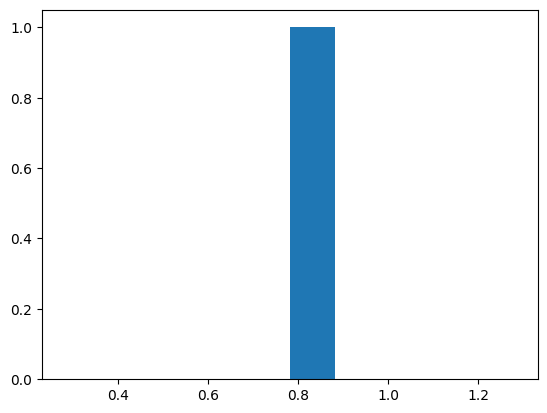

In [8]:
plt.hist(ratios, bins=10)

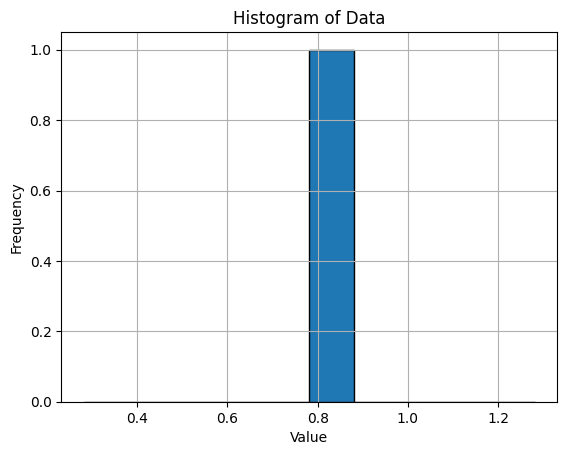

In [9]:
plt.hist(ratios, bins=10, edgecolor='black')
plt.title('Histogram of Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [10]:
ratios

array([0.7813771])

In [11]:
np.mean(ratios)

np.float64(0.781377095968605)

In [13]:
pruned_params

[91920]

In [12]:
base_params

[420450]

In [14]:
num_params

91920

## Model Evaluation

In [2]:
from inception import Classifier_INCEPTION
# dataset_names = ['BeetleFly']
ds_names = [ 
            'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
            'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  
            'BME', 
            'Car', 
            'CBF', 
            'Chinatown',
            'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
            'CricketY', 'CricketZ', 
            'DiatomSizeReduction',
            'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
            'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
            'ECG5000', 
            'ECGFiveDays',  
            'EOGHorizontalSignal', 
            'EthanolLevel', 
            'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
            'FiftyWords', 'Fish', 'FreezerRegularTrain',
            'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
            'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
            'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
            'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
            'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
            'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
            'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
            'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
            'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
            'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
            'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
            'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
            'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
            'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
            'Rock', 'ScreenType', 'SemgHandGenderCh2', 
            'SemgHandMovementCh2',
            'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
            'SmallKitchenAppliances', 'SmoothSubspace', 
            'SonyAIBORobotSurface1',
            'SonyAIBORobotSurface2', 
            'StarLightCurves', 
            'Strawberry', 'SwedishLeaf',
            'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 
            'Trace',
            'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
            'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
            'UWaveGestureLibraryZ', 
            'Wafer',  
            'Worms', 'WormsTwoClass',
            
            'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
            
            ]

columns=['Dataset', 'base_red_1', 'base_red_2', 'base_red_3',  'sparse_red_1', 'sparse_red_2', 'sparse_red_3',]
# columns=['Dataset', 'base_red_3',  'sparse_red_3',]

redundancy_df = pd.DataFrame(columns=columns)
seed = 9409

for dataset in ds_names:
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, mini_batch_size=64)
    testloader = preprocess_data(xtest, ytest, mini_batch_size=64)
    
    input_shape = xtrain.shape[1:]
    nb_classes = len(np.unique(ytrain))
    
    model_base = Classifier_INCEPTION(input_shape, nb_classes, nb_filters=np.array([[32, 32, 32, 32],
                                                                                    [32, 32, 32, 32],
                                                                                    [32, 32, 32, 32],
                                                                                    [32, 32, 32, 32],
                                                                                    [32, 32, 32, 32],
                                                                                    [32, 32, 32, 32]]),)
    
                                          
    # num_params = sum([torch.numel(param[1]) for param in model_base.named_parameters()])   
    # ratios.append(num_params/420000)
    # print(f'Dataset: {dataset} and parameters: {num_params}')

In [3]:
from torch.cuda.amp import autocast

def evaluate_ensemble_base(models, dataloader):
    models = [model.eval() for model in models]
    models = [model.cuda() for model in models]
    
    all_preds = []
    all_targets = []

    with torch.no_grad():

        for data, target in dataloader:
            data, target = data.cuda(), target.cuda()

            outputs = [model(data.float()) for model in models]
            probs = [F.softmax(output, dim=1) for output in outputs]
            
            avg_probs = sum(probs) / len(probs)

            preds = avg_probs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    accuracy = accuracy_score(all_targets, all_preds)
    return accuracy

In [ ]:
dataset_names = [ 
                    'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
                    'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  'BME', 'Car', 'CBF', 'Chinatown',
                    'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
                    'CricketY', 'CricketZ', 
                    'DiatomSizeReduction',
                    'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
                    'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
                    'ECG5000', 'ECGFiveDays',  'EOGHorizontalSignal', 'EthanolLevel', 
                    'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
                    'FiftyWords', 'Fish', 'FreezerRegularTrain',
                    'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
                    'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
                    'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
                    'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
                    'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
                    'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
                    'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
                    'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
                    'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
                    'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
                    'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
                    'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
                    'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
                    'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
                    'Rock', 'ScreenType', 'SemgHandGenderCh2', 'SemgHandMovementCh2',
                    'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
                    'SmallKitchenAppliances', 'SmoothSubspace', 'SonyAIBORobotSurface1',
                    'SonyAIBORobotSurface2', 'StarLightCurves', 'Strawberry', 'SwedishLeaf',
                    'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 'Trace',
                    'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
                    'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
                    'UWaveGestureLibraryZ', 'Wafer',  'Worms', 'WormsTwoClass',     
                                    
                    'Crop', 
                    'ElectricDevices',  
                    
                    'FordA', 
                    'FordB', 
                    'HandOutlines',
                    
                    ]

# columns=['Dataset', 'base_ens_acc', 'base_params', 'finetune_prune_ens_acc', 'finetune_prune_params', 'scratch_prune_ens_acc', 'scratch_prune_params']
columns=['Dataset', 'base_ens_acc', 'base_params', 'base_64_ens_acc', 'base_64_params',  'base_32_ens_acc', 'base_32_params', 'base_16_ens_acc', 'base_16_params', 'finetune_prune_ens_acc', 'finetune_prune_params', 'scratch_prune_ens_acc', 'scratch_prune_params']
# columns=['Dataset', 'base_ens_acc', 'base_params', 'base_64_ens_acc', 'base_64_params', 'base_16_ens_acc', 'base_16_params', 'finetune_prune_ens_acc', 'finetune_prune_params', 'scratch_prune_ens_acc', 'scratch_prune_params']

# columns=['Dataset', 'base_ens_acc', 'base_params']


tmp_df = pd.DataFrame(columns=columns)
seeds = [9409, 5296, 3952, 3804, 2561]

for dataset in dataset_names:
    print(f'Dataset: {dataset}')
    rows = [dataset]
    models_base, models_base_64,  models_base_32, models_base_16, models_prune_dynamic, models_prune_scratch = [], [], [], [], [], []
    base_params, base_params_64,  base_params_32, base_params_16, prune_dynamic_params, prune_scratch_params = 0, 0, 0, 0, 0, 0
    
    for seed in seeds:
        xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
        trainloader = preprocess_data(xtrain, ytrain, mini_batch_size=64)
        testloader = preprocess_data(xtest, ytest, mini_batch_size=64)
        
        input_shape = xtrain.shape[1:]
        nb_classes = len(np.unique(ytrain))

        model_base = Classifier_INCEPTION(input_shape, nb_classes, nb_filters=np.array([[32, 32, 32, 32],
                                                                                        [32, 32, 32, 32],
                                                                                        [32, 32, 32, 32],
                                                                                        [32, 32, 32, 32],
                                                                                        [32, 32, 32, 32],
                                                                                        [32, 32, 32, 32]]),)        
        
        model_base.load_state_dict(torch.load(os.getcwd() + f'/results_inception/base_models/base_seed_{seed}/{dataset}/best_model.pt'))

        base_params += sum(p.numel() for p in model_base.parameters())
        model_base.cuda()
        model_base.eval()
        models_base.append(model_base)
        
        model_base_64 = Classifier_INCEPTION(input_shape, nb_classes, nb_filters=np.array([[16, 16, 16, 16],
                                                                                           [16, 16, 16, 16],
                                                                                           [16, 16, 16, 16],
                                                                                           [16, 16, 16, 16],
                                                                                           [16, 16, 16, 16],
                                                                                           [16, 16, 16, 16]]),)        

        model_base_64.load_state_dict(torch.load(os.getcwd() + f'/results_inception/base_models_64/base_seed_{seed}/{dataset}/best_model.pt'))

        base_params_64 += sum(p.numel() for p in model_base_64.parameters())
        model_base_64.cuda()
        model_base_64.eval()
        models_base_64.append(model_base_64)
        
        
        model_base_32 = Classifier_INCEPTION(input_shape, nb_classes, nb_filters=np.array([[8, 8, 8, 8],
                                                                                           [8, 8, 8, 8],
                                                                                           [8, 8, 8, 8],
                                                                                           [8, 8, 8, 8],
                                                                                           [8, 8, 8, 8],
                                                                                           [8, 8, 8, 8]]),)        

        model_base_32.load_state_dict(torch.load(os.getcwd() + f'/results_inception/base_models_32/base_seed_{seed}/{dataset}/best_model.pt'))
        base_params_32 += sum(p.numel() for p in model_base_32.parameters())
        model_base_32.cuda()
        model_base_32.eval()
        models_base_32.append(model_base_32)


        model_base_16 = Classifier_INCEPTION(input_shape, nb_classes, nb_filters=np.array([[4, 4, 4, 4],
                                                                                           [4, 4, 4, 4],
                                                                                           [4, 4, 4, 4],
                                                                                           [4, 4, 4, 4],
                                                                                           [4, 4, 4, 4],
                                                                                           [4, 4, 4, 4]]),)        

        model_base_16.load_state_dict(torch.load(os.getcwd() + f'/results_inception/base_models_16/base_seed_{seed}/{dataset}/best_model.pt'))
        base_params_16 += sum(p.numel() for p in model_base_16.parameters())
        model_base_16.cuda()
        model_base_16.eval()
        models_base_16.append(model_base_16)



        
        model_prune_dynamic = torch.load(os.getcwd() + f'/results_inception/finetune_1e-5_weights_1_1_1_with_lr_scheduler_epochs_500/ins_sparse_seed_{seed}/{dataset}/best_model.pth')
        models_prune_dynamic.append(model_prune_dynamic)
        prune_dynamic_params += sum(p.numel() for p in model_prune_dynamic.parameters())
        
        model_prune_scratch = torch.load(os.getcwd() + f'/results_inception/scratch_training_1e-5_weights_1_1_1_epochs_1500/ins_sparse_seed_{seed}/{dataset}/best_model.pth')
        models_prune_scratch.append(model_prune_scratch)
        prune_scratch_params += sum(p.numel() for p in model_prune_scratch.parameters())
        
        
                    
    base_ens_acc = evaluate_ensemble_base(models_base, testloader)     
    rows.append(base_ens_acc)
    rows.append(base_params / 5)
    
    base_ens_acc = evaluate_ensemble_base(models_base_64, testloader)     
    rows.append(base_ens_acc)
    rows.append(base_params_64 / 5)

    base_ens_acc = evaluate_ensemble_base(models_base_32, testloader)     
    rows.append(base_ens_acc)
    rows.append(base_params_32 / 5)


    base_ens_acc = evaluate_ensemble_base(models_base_16, testloader)     
    rows.append(base_ens_acc)
    rows.append(base_params_16 / 5)


    prune_dynamic_ens_acc = evaluate_ensemble_base(models_prune_dynamic, testloader)     
    rows.append(prune_dynamic_ens_acc)
    rows.append(prune_dynamic_params / 5)
       
    prune_scratch_ens_acc = evaluate_ensemble_base(models_prune_scratch, testloader)     
    rows.append(prune_scratch_ens_acc)
    rows.append(prune_scratch_params / 5)
       
    tmp_df = pd.concat([tmp_df, pd.DataFrame([rows], columns=columns)])

In [11]:
tmp_df['base_16_ens_acc'].mean()

np.float64(0.8413345622112796)

In [12]:
tmp_df['base_32_ens_acc'].mean()

np.float64(0.8439280688253357)

In [13]:
tmp_df['base_64_ens_acc'].mean()


np.float64(0.8447804155928239)

In [ ]:
tmp_df['base_32_ens_acc'].mean()

np.float64(0.8451635348706336)

In [16]:
tmp_df['scratch_prune_ens_acc'].mean()


np.float64(0.8409234602704356)

In [ ]:
75%

In [17]:
1 - 32/128

0.75

In [19]:
stat, p_value_st = wilcoxon(tmp_df['base_16_ens_acc'].tolist(), tmp_df['base_32_ens_acc'])
p_value_st

np.float64(0.0035274640782294005)

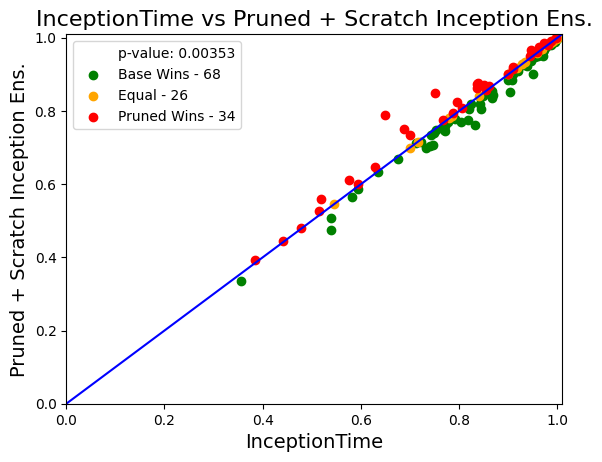

In [22]:
from utils import plot_1v1_perf
from scipy.stats import wilcoxon


stat, p_value_st = wilcoxon(tmp_df['base_16_ens_acc'].tolist(), tmp_df['base_32_ens_acc'])

plot_1v1_perf(tmp_df, 
              np.round(p_value_st, 5), 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='base_16_ens_acc', 
              base_col='base_32_ens_acc', 
              xlabel='InceptionTime', 
              ylabel='Pruned + Scratch Inception Ens.', 
              legend_base='Base', 
              legend_co='Pruned', 
              title='InceptionTime vs Pruned + Scratch Inception Ens.', 
              file_name='fig_2')

In [21]:
stat, p_value_st = wilcoxon(tmp_df['base_16_ens_acc'].tolist(), tmp_df['scratch_prune_ens_acc'])
p_value_st

np.float64(0.3163274515539599)

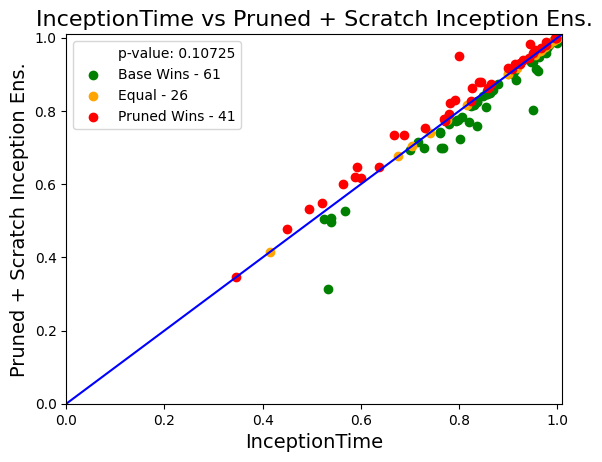

In [9]:
from utils import plot_1v1_perf
from scipy.stats import wilcoxon


stat, p_value_st = wilcoxon(tmp_df['base_ens_acc'].tolist(), tmp_df['scratch_prune_ens_acc'])

plot_1v1_perf(tmp_df, 
              np.round(p_value_st, 5), 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='scratch_prune_ens_acc', 
              base_col='base_ens_acc', 
              xlabel='InceptionTime', 
              ylabel='Pruned + Scratch Inception Ens.', 
              legend_base='Base', 
              legend_co='Pruned', 
              title='InceptionTime vs Pruned + Scratch Inception Ens.', 
              file_name='fig_2')

In [8]:
1 - 16/128

0.875

In [ ]:
columns=['Dataset', 'base_ens_acc', 'base_params', 'base_64_ens_acc', 'base_64_params',  'base_32_ens_acc', 'base_32_params', 'base_16_ens_acc', 'base_16_params', 'finetune_prune_ens_acc', 'finetune_prune_params', 'scratch_prune_ens_acc', 'scratch_prune_params']


In [6]:
tmp_df[['Dataset', 'base_ens_acc', 'base_params', 'scratch_prune_ens_acc', 'scratch_prune_params']]

,Dataset,base_ens_acc,base_params,scratch_prune_ens_acc,scratch_prune_params
0,ACSF1,0.930000,421482.0,0.940000,86869.0
0,Adiac,0.849105,424965.0,0.841432,267427.8
0,AllGestureWiimoteX,0.780000,421482.0,0.765714,116700.6
0,AllGestureWiimoteY,0.830000,421482.0,0.817143,143204.2
0,AllGestureWiimoteZ,0.792857,421482.0,0.771429,106478.4
...,...,...,...,...,...
0,Crop,0.771012,423288.0,0.772440,253932.6
0,ElectricDevices,0.716639,421095.0,0.714175,197250.6
0,FordA,0.962879,420450.0,0.956061,52433.0
0,FordB,0.856790,420450.0,0.845679,57966.2


In [8]:
32/128


0.25

In [12]:
# tmp_df['prune_ratio'] = 1 - (tmp_df['base_16_params'] / tmp_df['base_params'])
tmp_df['prune_ratio_inc'] = 1 - (tmp_df['scratch_prune_params'] / tmp_df['base_params'])


In [14]:
tmp_df['prune_ratio_inc'].mean()

np.float64(0.7452835310124217)

In [15]:
print(f'Minimum pruning ratio: {tmp_df['prune_ratio_inc'].min()}')
print(f'Maximum pruning ratio: {tmp_df['prune_ratio_inc'].max()}')
print(f'Average pruning ratio: {tmp_df['prune_ratio_inc'].mean()}')
print(f'Median pruning ratio: {tmp_df['prune_ratio_inc'].median()}')



Minimum pruning ratio: 0.3044252586514449
Maximum pruning ratio: 0.9759253181115471
Average pruning ratio: 0.7452835310124217
Median pruning ratio: 0.7833694026429132


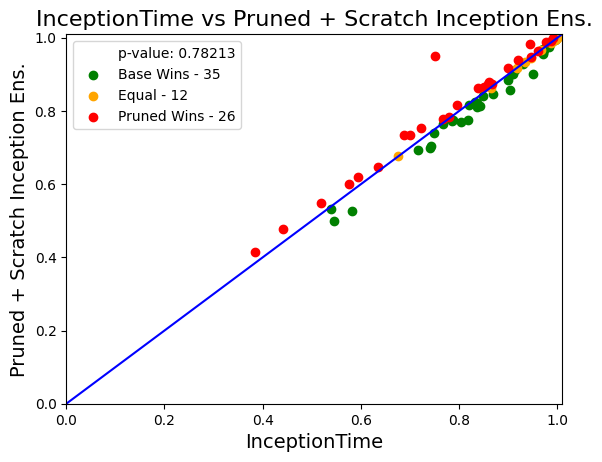

In [ ]:
stat, p_value_st = wilcoxon(tmp_df['base_32_ens_acc'].tolist(), tmp_df['scratch_prune_ens_acc'])

plot_1v1_perf(tmp_df, 
              np.round(p_value_st, 5), 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='scratch_prune_ens_acc', 
              base_col='base_32_ens_acc', 
              xlabel='InceptionTime', 
              ylabel='Pruned + Scratch Inception Ens.', 
              legend_base='Base', 
              legend_co='Pruned', 
              title='InceptionTime vs Pruned + Scratch Inception Ens.', 
              file_name='fig_2')

In [32]:
from utils import plot_1v1_perf
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value_ft = wilcoxon(tmp_df['base_64_ens_acc'].tolist(), tmp_df['finetune_prune_ens_acc'])
stat, p_value_st = wilcoxon(tmp_df['base_64_ens_acc'].tolist(), tmp_df['scratch_prune_ens_acc'])
stat, p_value_ss = wilcoxon(tmp_df['base_64_ens_acc'].tolist(), tmp_df['base_ens_acc'])

print(f'p_value [Base_64 and Finetune]: {p_value_ft}')
print(f'p_value [Base_64 and Scratch]: {p_value_st}')
print(f'p_value [Base_64 and Base_132]: {p_value_ss}')

print('--------------------------------------------------------------------------------------------------')

# Perform the Wilcoxon signed-rank test
stat, p_value_ft = wilcoxon(tmp_df['base_32_ens_acc'].tolist(), tmp_df['finetune_prune_ens_acc'])
stat, p_value_st = wilcoxon(tmp_df['base_32_ens_acc'].tolist(), tmp_df['scratch_prune_ens_acc'])
stat, p_value_ss = wilcoxon(tmp_df['base_32_ens_acc'].tolist(), tmp_df['base_ens_acc'])

print(f'p_value [Base_32 and Finetune]: {p_value_ft}')
print(f'p_value [Base_32 and Scratch]: {p_value_st}')
print(f'p_value [Base_32 and Base_132]: {p_value_ss}')


print('--------------------------------------------------------------------------------------------------')

# Perform the Wilcoxon signed-rank test
stat, p_value_ft = wilcoxon(tmp_df['base_16_ens_acc'].tolist(), tmp_df['finetune_prune_ens_acc'])
stat, p_value_st = wilcoxon(tmp_df['base_16_ens_acc'].tolist(), tmp_df['scratch_prune_ens_acc'])
stat, p_value_ss = wilcoxon(tmp_df['base_16_ens_acc'].tolist(), tmp_df['base_ens_acc'])

print(f'p_value [Base_16 and Finetune]: {p_value_ft}')
print(f'p_value [Base_16 and Scratch]: {p_value_st}')
print(f'p_value [Base_16 and Base_132]: {p_value_ss}')


print('--------------------------------------------------------------------------------------------------')


stat, p_value_ft = wilcoxon(tmp_df['base_ens_acc'].tolist(), tmp_df['finetune_prune_ens_acc'])
stat, p_value_st = wilcoxon(tmp_df['base_ens_acc'].tolist(), tmp_df['scratch_prune_ens_acc'])
print(f'p_value [Base and Finetune]: {p_value_ft}')
print(f'p_value [Base and Scratch]: {p_value_st}')

p_value [Base_64 and Finetune]: 0.05144263411487311
p_value [Base_64 and Scratch]: 0.18443752396762902
p_value [Base_64 and Base_132]: 0.6659054577661125
--------------------------------------------------------------------------------------------------
p_value [Base_32 and Finetune]: 0.01851208374442086
p_value [Base_32 and Scratch]: 0.1987335106362803
p_value [Base_32 and Base_132]: 0.4297895801496767
--------------------------------------------------------------------------------------------------
p_value [Base_16 and Finetune]: 0.9895003803876549
p_value [Base_16 and Scratch]: 0.3163274515539599
p_value [Base_16 and Base_132]: 0.007119389992876049
--------------------------------------------------------------------------------------------------
p_value [Base and Finetune]: 0.008952865719551364
p_value [Base and Scratch]: 0.10725033532541155


In [1]:
tmp_df

NameError: name 'tmp_df' is not defined

In [11]:
tmp_df.shape

(42, 11)

In [ ]:
print(f'Minimum pruning ratio: {tmp_df['prune_ratio'].min()}')
print(f'Maximum pruning ratio: {tmp_df['prune_ratio'].max()}')
print(f'Average pruning ratio: {tmp_df['prune_ratio'].mean()}')
print(f'Median pruning ratio: {tmp_df['prune_ratio'].median()}')



In [161]:
tmp_df.shape

(128, 7)

In [ ]:
tmp_df[['Dataset', 'base_ens_acc', 'finetune_prune_ens_acc', 'scratch_prune_ens_acc']][-20:]

In [41]:
# Perform the Wilcoxon signed-rank test
stat, p_value_ft = wilcoxon(tmp_df['base_ens_acc'].tolist(), tmp_df['finetune_prune_ens_acc'])
stat, p_value_st = wilcoxon(tmp_df['base_16_ens_acc'].tolist(), tmp_df['base_ens_acc'])
print(f'p_value [Base and Finetune]: {p_value_ft}')
print(f'p_value [Base and Scratch]: {p_value_st}')

p_value [Base and Finetune]: 0.008952865719551364
p_value [Base and Scratch]: 0.007119389992876049


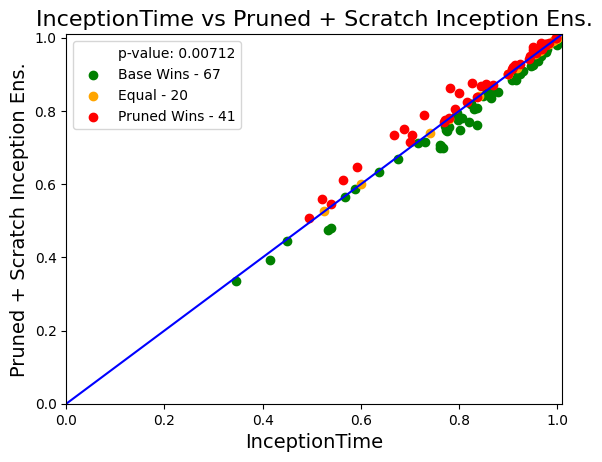

In [42]:
plot_1v1_perf(tmp_df, 
              np.round(p_value_st, 5), 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='base_16_ens_acc', 
              base_col='base_ens_acc', 
              xlabel='InceptionTime', 
              ylabel='Pruned + Scratch Inception Ens.', 
              legend_base='Base', 
              legend_co='Pruned', 
              title='InceptionTime vs Pruned + Scratch Inception Ens.', 
              file_name='fig_2_')

p_value:  0.008952865719551364


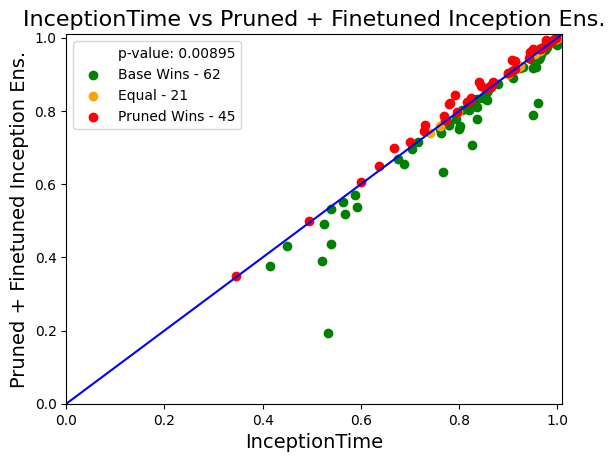

In [184]:
from utils import plot_1v1_perf
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(tmp_df['base_ens_acc'].tolist(), tmp_df['finetune_prune_ens_acc'])
print('p_value: ', p_value)

plot_1v1_perf(tmp_df, 
              np.round(p_value_ft, 5), 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='finetune_prune_ens_acc', 
              base_col='base_ens_acc', 
              xlabel='InceptionTime', 
              ylabel='Pruned + Finetuned Inception Ens.', 
              legend_base='Base', 
              legend_co='Pruned', 
              title='InceptionTime vs Pruned + Finetuned Inception Ens.', 
              file_name='fig_1')

In [9]:
tmp_df['prune_ratio'] = 1 - (tmp_df['scratch_prune_params'] / tmp_df['base_params'])
tmp_df

,Dataset,base_ens_acc,base_params,base_16_ens_acc,base_16_params,finetune_prune_ens_acc,finetune_prune_params,scratch_prune_ens_acc,scratch_prune_params,prune_ratio
0,ACSF1,0.930000,421482.0,0.920000,98466.0,0.920000,86869.0,0.940000,86869.0,0.793896
0,Adiac,0.849105,424965.0,0.849105,99357.0,0.836317,267427.8,0.841432,267427.8,0.370706
0,AllGestureWiimoteX,0.780000,421482.0,0.767143,98466.0,0.761429,116700.6,0.765714,116700.6,0.723118
0,AllGestureWiimoteY,0.830000,421482.0,0.820000,98466.0,0.812857,143204.2,0.817143,143204.2,0.660236
0,AllGestureWiimoteZ,0.792857,421482.0,0.785714,98466.0,0.777143,106478.4,0.771429,106478.4,0.747371
...,...,...,...,...,...,...,...,...,...,...
0,Crop,0.771012,423288.0,0.770595,98928.0,0.770774,253932.6,0.772440,253932.6,0.400095
0,ElectricDevices,0.716639,421095.0,0.711321,98367.0,0.715471,197250.6,0.714175,197250.6,0.531577
0,FordA,0.962879,420450.0,0.959091,98202.0,0.959091,52433.0,0.956061,52433.0,0.875293
0,FordB,0.856790,420450.0,0.855556,98202.0,0.853086,57966.2,0.845679,57966.2,0.862133


In [10]:
tmp_df['prune_ratio'].mean()

np.float64(0.7452835310124217)

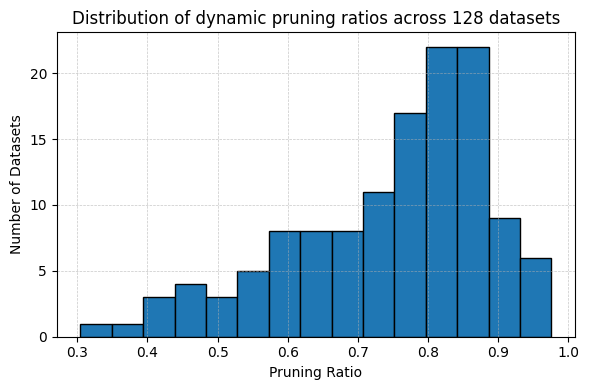

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
tmp_df['prune_ratio'].hist(bins=15, edgecolor='black')
plt.title('Distribution of dynamic pruning ratios across 128 datasets')
plt.xlabel('Pruning Ratio')
plt.ylabel('Number of Datasets')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.savefig('dynamic_pruning_hist_inc.pdf')  

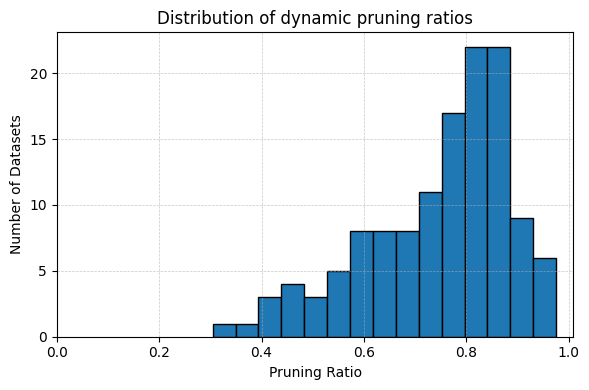

In [15]:
import matplotlib.pyplot as plt

# Assuming tmp_df['prune_ratio'] exists and is the column to be plotted
plt.figure(figsize=(6, 4))
plt.hist(tmp_df['prune_ratio'], bins=15, edgecolor='black')
plt.title('Distribution of dynamic pruning ratios')
plt.xlabel('Pruning Ratio')
plt.ylabel('Number of Datasets')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlim(left=0.0)  # Set the x-axis to start from 0.0
plt.tight_layout()
plt.savefig('dynamic_pruning_hist_inc.pdf')  

plt.show()


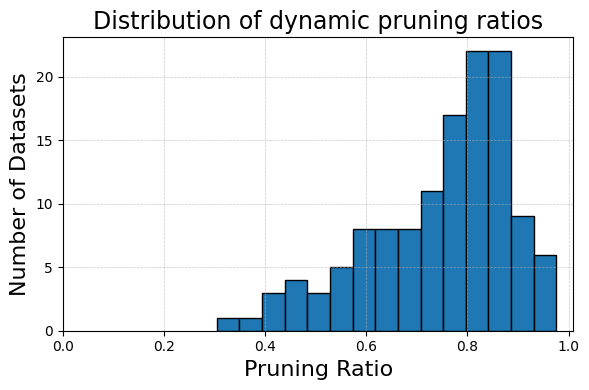

In [23]:
import matplotlib.pyplot as plt

# Assuming tmp_df['prune_ratio'] exists and is the column to be plotted
plt.figure(figsize=(6, 4))
plt.hist(tmp_df['prune_ratio'], bins=15, edgecolor='black')
plt.title('Distribution of dynamic pruning ratios', fontsize=17)  # Increased title font size
plt.xlabel('Pruning Ratio', fontsize=16)  # Increased x-axis label font size
plt.ylabel('Number of Datasets', fontsize=16)  # Increased y-axis label font size
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlim(left=0.0)  # Set the x-axis to start from 0.0
plt.tight_layout()
plt.savefig('dynamic_pruning_hist_inc.pdf')  

plt.show()


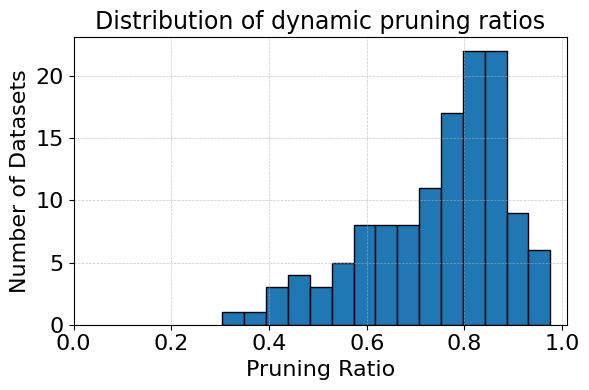

In [24]:
import matplotlib.pyplot as plt

# Assuming tmp_df['prune_ratio_dynamic_1l'] exists and is the column to be plotted
plt.figure(figsize=(6, 4))
plt.hist(tmp_df['prune_ratio'], bins=15, edgecolor='black')
plt.title('Distribution of dynamic pruning ratios', fontsize=17)  # Increased title font size
plt.xlabel('Pruning Ratio', fontsize=16)  # Increased x-axis label font size
plt.ylabel('Number of Datasets', fontsize=16)  # Increased y-axis label font size
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlim(left=0.0)  # Set the x-axis to start from 0.0

# Increase tick size for both axes
plt.tick_params(axis='both', labelsize=16)  # Set tick label size for both x and y axes

plt.tight_layout()
plt.savefig('dynamic_pruning_hist_inc.pdf')  

plt.show()


In [18]:
# tmp_df['prune_ratio_inc'] *= 100

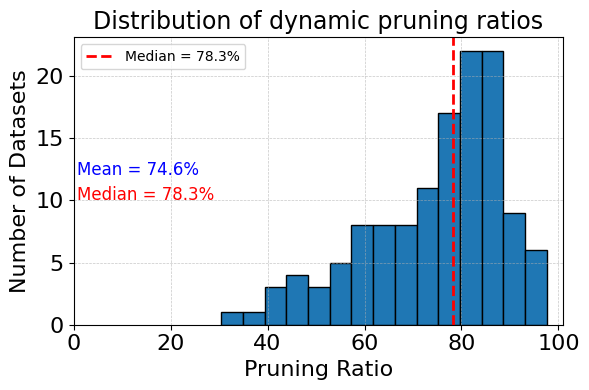

In [19]:
import matplotlib.pyplot as plt

# Assuming tmp_df['prune_ratio_dynamic_1l'] exists and is the column to be plotted
mean_prune_ratio = 74.6  # Mean pruning ratio
median_prune_ratio = 78.3  # Median pruning ratio
# tmp_df['prune_ratio_lite'] = tmp_df['prune_ratio_lite'] / 100
plt.figure(figsize=(6, 4))
plt.hist(tmp_df['prune_ratio_inc'], bins=15, edgecolor='black')

# Adding the vertical red line at the median pruning ratio
plt.axvline(median_prune_ratio, color='red', linestyle='dashed', linewidth=2, label=f'Median = {median_prune_ratio}%')

# Adding title and labels with increased font size
plt.title('Distribution of dynamic pruning ratios', fontsize=17)
plt.xlabel('Pruning Ratio', fontsize=16)
plt.ylabel('Number of Datasets', fontsize=16)

# Adding text to show the mean and median
plt.text(0.6, 12, f'Mean = {mean_prune_ratio}%', fontsize=12, color='blue')
plt.text(0.6, 10, f'Median = {median_prune_ratio}%', fontsize=12, color='red')

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlim(left=0.0)  # Set the x-axis to start from 0.0

# Show legend
plt.legend()

# Increase tick size for both axes
plt.tick_params(axis='both', labelsize=16)

plt.tight_layout()
plt.savefig('dynamic_pruning_hist_inc_with_stats.pdf')  

plt.show()


In [216]:
lower_df = tmp_df[tmp_df['prune_ratio'] <= tmp_df['prune_ratio'].mean()]

In [219]:
print(f'Wins: {lower_df[lower_df['scratch_prune_ens_acc'] > lower_df['base_ens_acc']].shape}')
print(f'Ties {lower_df[lower_df['scratch_prune_ens_acc'] == lower_df['base_ens_acc']].shape}')
print(f'Loss {lower_df[lower_df['scratch_prune_ens_acc'] < lower_df['base_ens_acc']].shape}')

Wins: (15, 8)
Ties (9, 8)
Loss (26, 8)


In [220]:
higher_df = tmp_df[tmp_df['prune_ratio'] > tmp_df['prune_ratio'].mean()]


In [221]:
print(f'Wins: {higher_df[higher_df['scratch_prune_ens_acc'] > higher_df['base_ens_acc']].shape}')
print(f'Ties: {higher_df[higher_df['scratch_prune_ens_acc'] == higher_df['base_ens_acc']].shape}')
print(f'Loss: {higher_df[higher_df['scratch_prune_ens_acc'] < higher_df['base_ens_acc']].shape}')

Wins: (26, 8)
Ties: (17, 8)
Loss: (35, 8)


In [ ]:
dataset_names = [ 
                    'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
                    'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  'BME', 'Car', 'CBF', 'Chinatown',
                    'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
                    'CricketY', 'CricketZ', 
                    'DiatomSizeReduction',
                    'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
                    'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
                    'ECG5000', 'ECGFiveDays',  'EOGHorizontalSignal', 'EthanolLevel', 
                    'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
                    'FiftyWords', 'Fish', 'FreezerRegularTrain',
                    'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
                    'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
                    'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
                    'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
                    'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
                    'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
                    'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
                    'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
                    'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
                    'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
                    'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
                    'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
                    'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
                    'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
                    'Rock', 'ScreenType', 'SemgHandGenderCh2', 'SemgHandMovementCh2',
                    'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
                    'SmallKitchenAppliances', 'SmoothSubspace', 'SonyAIBORobotSurface1',
                    'SonyAIBORobotSurface2', 'StarLightCurves', 'Strawberry', 'SwedishLeaf',
                    'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 'Trace',
                    'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
                    'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
                    'UWaveGestureLibraryZ', 'Wafer',  'Worms', 'WormsTwoClass',     
                                    
                    'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
                    
                    ]

columns=['Dataset', 'base_ens_acc', 'base_params', 'finetune_prune_ens_acc', 'finetune_prune_params', 'scratch_prune_ens_acc', 'scratch_prune_params']
columns=['Dataset', 'base_ens_acc', 'base_params', 'scratch_prune_ens_acc', 'scratch_prune_params']
# columns=['Dataset', 'base_ens_acc', 'base_params', 'base_64_ens_acc', 'base_64_params',  'base_32_ens_acc', 'base_32_params', 'base_16_ens_acc', 'base_16_params', 'finetune_prune_ens_acc', 'finetune_prune_params', 'scratch_prune_ens_acc', 'scratch_prune_params']
# columns=['Dataset', 'base_ens_acc', 'base_params']


tmp_df = pd.DataFrame(columns=columns)
seeds = [9409, 5296, 3952, 3804, 2561]

for dataset in dataset_names:
    print(f'Dataset: {dataset}')
    rows = [dataset]
    models_base, models_base_64,  models_base_32, models_base_16, models_prune_dynamic, models_prune_scratch = [], [], [], [], [], []
    base_params, base_params_64,  base_params_32, base_params_16, prune_dynamic_params, prune_scratch_params = 0, 0, 0, 0, 0, 0
    
    for seed in seeds:
        xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
        trainloader = preprocess_data(xtrain, ytrain, mini_batch_size=64)
        testloader = preprocess_data(xtest, ytest, mini_batch_size=64)
        
        input_shape = xtrain.shape[1:]
        nb_classes = len(np.unique(ytrain))

        model_base = Classifier_INCEPTION(input_shape, nb_classes, nb_filters=np.array([[32, 32, 32, 32],
                                                                                        [32, 32, 32, 32],
                                                                                        [32, 32, 32, 32],
                                                                                        [32, 32, 32, 32],
                                                                                        [32, 32, 32, 32],
                                                                                        [32, 32, 32, 32]]),)        
        
        model_base.load_state_dict(torch.load(os.getcwd() + f'/results_inception/base_models/base_seed_{seed}/{dataset}/best_model.pt'))

        base_params += sum(p.numel() for p in model_base.parameters())
        model_base.cuda()
        model_base.eval()
        models_base.append(model_base)
        
        model_prune_scratch = torch.load(os.getcwd() + f'/results_inception/scratch_training_1e-5_weights_1_1_1_epochs_1500/ins_sparse_seed_{seed}/{dataset}/best_model.pth')
        models_prune_scratch.append(model_prune_scratch)
        prune_scratch_params += sum(p.numel() for p in model_prune_scratch.parameters())
        
        
                    
    base_ens_acc = evaluate_ensemble_base(models_base, testloader)     
    rows.append(base_ens_acc)
    rows.append(base_params / 5)
       
    prune_scratch_ens_acc = evaluate_ensemble_base(models_prune_scratch, testloader)     
    rows.append(prune_scratch_ens_acc)
    rows.append(prune_scratch_params / 5)
       
    tmp_df = pd.concat([tmp_df, pd.DataFrame([rows], columns=columns)])

In [28]:
tmp_df['prune_ratio'] = 1 - tmp_df['scratch_prune_params'] / tmp_df['base_params']

In [29]:
tmp_df['prune_ratio'].mean()

np.float64(0.7452835310124217)

In [30]:
tmp_df['perf_diff'] = tmp_df['scratch_prune_ens_acc'] - tmp_df['base_ens_acc']

In [31]:
tmp_df.sort_values(['perf_diff'], ascending=False)

,Dataset,base_ens_acc,base_params,scratch_prune_ens_acc,scratch_prune_params,prune_ratio,perf_diff
0,BeetleFly,0.800000,420450.0,0.950000,82348.6,0.804142,0.150000
0,Beef,0.666667,420837.0,0.733333,190810.8,0.546592,0.066667
0,Wine,0.592593,420450.0,0.648148,66134.2,0.842706,0.055556
0,Herring,0.687500,420450.0,0.734375,43213.6,0.897221,0.046875
0,Lightning7,0.780822,421095.0,0.821918,223106.2,0.470176,0.041096
...,...,...,...,...,...,...,...
0,OliveOil,0.766667,420708.0,0.700000,66275.2,0.842467,-0.066667
0,SemgHandGenderCh2,0.836667,420450.0,0.760000,27651.8,0.934233,-0.076667
0,SemgHandSubjectCh2,0.802222,420837.0,0.722222,109438.2,0.739951,-0.080000
0,UWaveGestureLibraryAll,0.950028,421224.0,0.802624,37011.4,0.912134,-0.147404


In [36]:
tmp_df.sort_values(['prune_ratio', 'perf_diff'], ascending=False)[:20]


,Dataset,base_ens_acc,base_params,scratch_prune_ens_acc,scratch_prune_params,prune_ratio,perf_diff
0,HandOutlines,0.956757,420450.0,0.913514,10122.2,0.975925,-0.043243
0,Wafer,0.997891,420450.0,0.999027,19918.4,0.952626,0.001136
0,InlineSkate,0.520000,421095.0,0.547273,21817.4,0.948189,0.027273
0,EthanolLevel,0.826000,420708.0,0.864000,25235.4,0.940017,0.038000
0,SemgHandGenderCh2,0.836667,420450.0,0.760000,27651.8,0.934233,-0.076667
0,ShapeletSim,0.727778,420450.0,0.700000,27998.6,0.933408,-0.027778
0,NonInvasiveFetalECGThorax1,0.961832,425610.0,0.948601,29608.6,0.930433,-0.013232
0,PigAirwayPressure,0.533654,426900.0,0.312500,30031.2,0.929653,-0.221154
0,StarLightCurves,0.977659,420579.0,0.980452,30018.8,0.928625,0.002793
0,PigCVP,0.961538,426900.0,0.908654,32175.8,0.924629,-0.052885


## LITE results

In [41]:
from lite_org import LITE

from torch.cuda.amp import autocast

def evaluate_ensemble_base_Lite(models, dataloader):
    models = [model.eval() for model in models]
    models = [model.cuda() for model in models]
    
    all_preds = []
    all_targets = []

    with torch.no_grad():

        for data, target in dataloader:
            data, target = data.cuda(), target.cuda()

            outputs = [model(data.float())[0] for model in models]
            probs = [F.softmax(output, dim=1) for output in outputs]
            
            avg_probs = sum(probs) / len(probs)

            preds = avg_probs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    accuracy = accuracy_score(all_targets, all_preds)
    return accuracy

In [ ]:
dataset_names = [ 
                    'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
                    'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  'BME', 'Car', 'CBF', 'Chinatown',
                    'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
                    'CricketY', 'CricketZ', 
                    'DiatomSizeReduction',
                    'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
                    'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
                    'ECG5000', 'ECGFiveDays',  'EOGHorizontalSignal', 'EthanolLevel', 
                    'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
                    'FiftyWords', 'Fish', 'FreezerRegularTrain',
                    'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
                    'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
                    'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
                    'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
                    'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
                    'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
                    'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
                    'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
                    'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
                    'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
                    'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
                    'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
                    'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
                    'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
                    'Rock', 'ScreenType', 'SemgHandGenderCh2', 'SemgHandMovementCh2',
                    'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
                    'SmallKitchenAppliances', 'SmoothSubspace', 'SonyAIBORobotSurface1',
                    'SonyAIBORobotSurface2', 'StarLightCurves', 'Strawberry', 'SwedishLeaf',
                    'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 'Trace',
                    'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
                    'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
                    'UWaveGestureLibraryZ', 'Wafer',  'Worms', 'WormsTwoClass',     
                                    
                    'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
                    
                    ]

# columns=['Dataset', 'base_ens_acc', 'base_params', 'finetune_prune_ens_acc', 'finetune_prune_params', 'scratch_prune_ens_acc', 'scratch_prune_params']
columns=['Dataset', 'base_ens_acc_lite', 'base_params_lite', 'scratch_prune_ens_acc_lite', 'scratch_prune_params_lite']
# columns=['Dataset', 'base_ens_acc', 'base_params', 'base_64_ens_acc', 'base_64_params',  'base_32_ens_acc', 'base_32_params', 'base_16_ens_acc', 'base_16_params', 'finetune_prune_ens_acc', 'finetune_prune_params', 'scratch_prune_ens_acc', 'scratch_prune_params']
# columns=['Dataset', 'base_ens_acc', 'base_params']


tmp_df_lite = pd.DataFrame(columns=columns)
seeds = [9409, 5296, 3952, 3804, 2561]

for dataset in dataset_names:
    print(f'Dataset: {dataset}')
    rows = [dataset]
    models_base, models_base_64,  models_base_32, models_base_16, models_prune_dynamic, models_prune_scratch = [], [], [], [], [], []
    base_params, base_params_64,  base_params_32, base_params_16, prune_dynamic_params, prune_scratch_params = 0, 0, 0, 0, 0, 0
    
    for seed in seeds:
        xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
        trainloader = preprocess_data(xtrain, ytrain, mini_batch_size=64)
        testloader = preprocess_data(xtest, ytest, mini_batch_size=64)
        
        length_TS = int(xtrain.shape[1])
        n_classes=len(np.unique(ytrain))


        model_base = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
        model_base.load_state_dict(torch.load(os.getcwd() + f'/results/base_models_32_filters/base_seed_{seed}/{dataset}/best_model.pt'))        
        base_params += sum(p.numel() for p in model_base.parameters())
        model_base.cuda()
        model_base.eval()
        models_base.append(model_base)
        
        model_prune_scratch = torch.load(os.getcwd() + f'/results/scratch_training_1e-5_weights_4_2_1_epochs_1500/ins_sparse_seed_{seed}/{dataset}/best_model.pth')
        models_prune_scratch.append(model_prune_scratch)
        prune_scratch_params += sum(p.numel() for p in model_prune_scratch.parameters())
        
        
                    
    base_ens_acc = evaluate_ensemble_base_Lite(models_base, testloader)     
    rows.append(base_ens_acc)
    rows.append(base_params / 5)
       
    prune_scratch_ens_acc = evaluate_ensemble_base_Lite(models_prune_scratch, testloader)     
    rows.append(prune_scratch_ens_acc)
    rows.append(prune_scratch_params / 5)
       
    tmp_df_lite = pd.concat([tmp_df_lite, pd.DataFrame([rows], columns=columns)])

In [45]:
fin_df = pd.merge(tmp_df, tmp_df_lite, on='Dataset')

In [46]:
fin_df

,Dataset,base_ens_acc,base_params,scratch_prune_ens_acc,scratch_prune_params,prune_ratio,perf_diff,base_ens_acc_lite,base_params_lite,scratch_prune_ens_acc_lite,scratch_prune_params_lite
0,ACSF1,0.930000,421482.0,0.940000,86869.0,0.793896,0.010000,0.910000,10582.0,0.900000,5172.6
1,Adiac,0.849105,424965.0,0.841432,267427.8,0.370706,-0.007673,0.846547,11473.0,0.833760,8770.8
2,AllGestureWiimoteX,0.780000,421482.0,0.765714,116700.6,0.723118,-0.014286,0.778571,10582.0,0.777143,7795.4
3,AllGestureWiimoteY,0.830000,421482.0,0.817143,143204.2,0.660236,-0.012857,0.812857,10582.0,0.818571,6330.6
4,AllGestureWiimoteZ,0.792857,421482.0,0.771429,106478.4,0.747371,-0.021429,0.757143,10582.0,0.755714,5468.2
...,...,...,...,...,...,...,...,...,...,...,...
123,Crop,0.771012,423288.0,0.772440,253932.6,0.400095,0.001429,0.761012,11044.0,0.757262,11031.2
124,ElectricDevices,0.716639,421095.0,0.714175,197250.6,0.531577,-0.002464,0.704837,10483.0,0.698872,9314.2
125,FordA,0.962879,420450.0,0.956061,52433.0,0.875293,-0.006818,0.956818,10318.0,0.958333,4884.4
126,FordB,0.856790,420450.0,0.845679,57966.2,0.862133,-0.011111,0.834568,10318.0,0.839506,5260.8


In [47]:
fin_df['prune_ratio_lite'] = 1 - fin_df['scratch_prune_params_lite'] / fin_df['base_params_lite']


In [48]:
fin_df['perf_diff_lite'] = fin_df['scratch_prune_ens_acc_lite'] - fin_df['base_ens_acc_lite']


In [49]:
fin_df

,Dataset,base_ens_acc,base_params,scratch_prune_ens_acc,scratch_prune_params,prune_ratio,perf_diff,base_ens_acc_lite,base_params_lite,scratch_prune_ens_acc_lite,scratch_prune_params_lite,prune_ratio_lite,perf_diff_lite
0,ACSF1,0.930000,421482.0,0.940000,86869.0,0.793896,0.010000,0.910000,10582.0,0.900000,5172.6,0.511189,-0.010000
1,Adiac,0.849105,424965.0,0.841432,267427.8,0.370706,-0.007673,0.846547,11473.0,0.833760,8770.8,0.235527,-0.012788
2,AllGestureWiimoteX,0.780000,421482.0,0.765714,116700.6,0.723118,-0.014286,0.778571,10582.0,0.777143,7795.4,0.263334,-0.001429
3,AllGestureWiimoteY,0.830000,421482.0,0.817143,143204.2,0.660236,-0.012857,0.812857,10582.0,0.818571,6330.6,0.401758,0.005714
4,AllGestureWiimoteZ,0.792857,421482.0,0.771429,106478.4,0.747371,-0.021429,0.757143,10582.0,0.755714,5468.2,0.483255,-0.001429
...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,Crop,0.771012,423288.0,0.772440,253932.6,0.400095,0.001429,0.761012,11044.0,0.757262,11031.2,0.001159,-0.003750
124,ElectricDevices,0.716639,421095.0,0.714175,197250.6,0.531577,-0.002464,0.704837,10483.0,0.698872,9314.2,0.111495,-0.005966
125,FordA,0.962879,420450.0,0.956061,52433.0,0.875293,-0.006818,0.956818,10318.0,0.958333,4884.4,0.526614,0.001515
126,FordB,0.856790,420450.0,0.845679,57966.2,0.862133,-0.011111,0.834568,10318.0,0.839506,5260.8,0.490134,0.004938


In [54]:
fin_df.sort_values(['prune_ratio'], ascending=False)[:10]

,Dataset,base_ens_acc,base_params,scratch_prune_ens_acc,scratch_prune_params,prune_ratio,perf_diff,base_ens_acc_lite,base_params_lite,scratch_prune_ens_acc_lite,scratch_prune_params_lite,prune_ratio_lite,perf_diff_lite
127,HandOutlines,0.956757,420450.0,0.913514,10122.2,0.975925,-0.043243,0.954054,10318.0,0.935135,1345.2,0.869626,-0.018919
120,Wafer,0.997891,420450.0,0.999027,19918.4,0.952626,0.001136,0.999189,10318.0,0.999027,1578.4,0.847025,-0.000162
55,InlineSkate,0.520000,421095.0,0.547273,21817.4,0.948189,0.027273,0.543636,10483.0,0.554545,2428.0,0.768387,0.010909
32,EthanolLevel,0.826000,420708.0,0.864000,25235.4,0.940017,0.038000,0.768000,10384.0,0.808000,991.0,0.904565,0.040000
92,SemgHandGenderCh2,0.836667,420450.0,0.760000,27651.8,0.934233,-0.076667,0.880000,10318.0,0.876667,3338.6,0.676430,-0.003333
96,ShapeletSim,0.727778,420450.0,0.700000,27998.6,0.933408,-0.027778,0.705556,10318.0,0.744444,2613.6,0.746695,0.038889
73,NonInvasiveFetalECGThorax1,0.961832,425610.0,0.948601,29608.6,0.930433,-0.013232,0.960305,11638.0,0.955725,6273.4,0.460955,-0.004580
80,PigAirwayPressure,0.533654,426900.0,0.312500,30031.2,0.929653,-0.221154,0.524038,11968.0,0.221154,3634.6,0.696307,-0.302885
102,StarLightCurves,0.977659,420579.0,0.980452,30018.8,0.928625,0.002793,0.977538,10351.0,0.977780,1689.0,0.836827,0.000243
82,PigCVP,0.961538,426900.0,0.908654,32175.8,0.924629,-0.052885,0.947115,11968.0,0.927885,4741.6,0.603810,-0.019231


In [53]:
fin_df.sort_values(['prune_ratio_lite'], ascending=False)[:10]


,Dataset,base_ens_acc,base_params,scratch_prune_ens_acc,scratch_prune_params,prune_ratio,perf_diff,base_ens_acc_lite,base_params_lite,scratch_prune_ens_acc_lite,scratch_prune_params_lite,prune_ratio_lite,perf_diff_lite
32,EthanolLevel,0.826000,420708.0,0.864000,25235.4,0.940017,0.038000,0.768000,10384.0,0.808000,991.0,0.904565,0.040000
127,HandOutlines,0.956757,420450.0,0.913514,10122.2,0.975925,-0.043243,0.954054,10318.0,0.935135,1345.2,0.869626,-0.018919
15,Coffee,1.000000,420450.0,1.000000,57307.0,0.863701,0.000000,1.000000,10318.0,1.000000,1562.4,0.848575,0.000000
120,Wafer,0.997891,420450.0,0.999027,19918.4,0.952626,0.001136,0.999189,10318.0,0.999027,1578.4,0.847025,-0.000162
100,SonyAIBORobotSurface1,0.836938,420450.0,0.826955,76215.0,0.818730,-0.009983,0.835275,10318.0,0.775374,1654.8,0.839620,-0.059900
102,StarLightCurves,0.977659,420579.0,0.980452,30018.8,0.928625,0.002793,0.977538,10351.0,0.977780,1689.0,0.836827,0.000243
40,FreezerSmallTrain,0.869474,420450.0,0.866667,132312.6,0.685307,-0.002807,0.930175,10318.0,0.927368,1725.4,0.832778,-0.002807
54,HouseTwenty,0.974790,420450.0,0.974790,80188.4,0.809280,0.000000,0.966387,10318.0,0.974790,1742.8,0.831091,0.008403
7,BirdChicken,0.900000,420450.0,0.900000,69469.0,0.834775,0.000000,0.900000,10318.0,0.950000,1773.2,0.828145,0.050000
101,SonyAIBORobotSurface2,0.964323,420450.0,0.956978,91196.8,0.783097,-0.007345,0.948583,10318.0,0.931794,1793.6,0.826168,-0.016789
